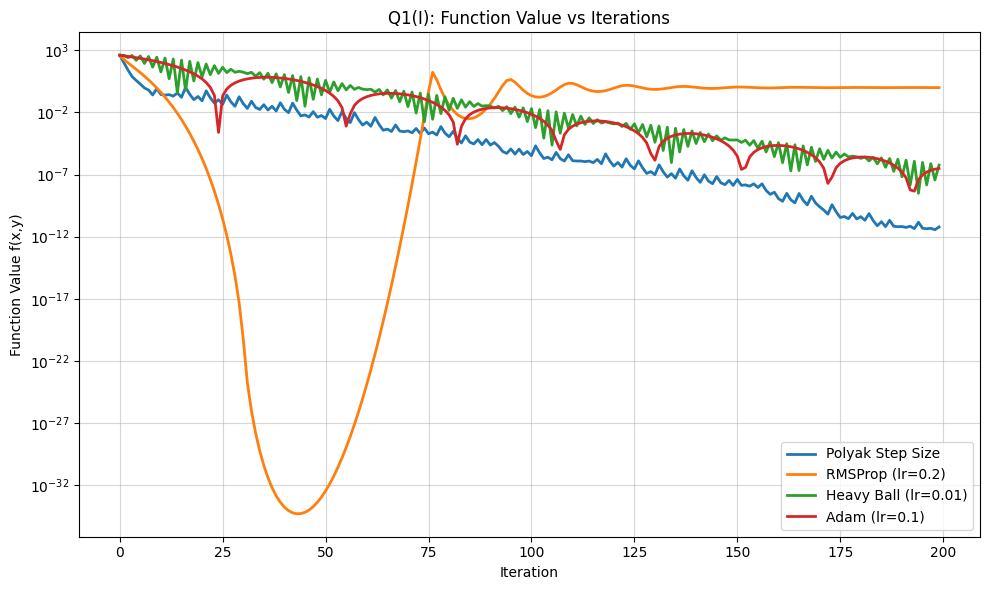

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the objective function and gradient
def func(w):
    x, y = w[0], w[1]
    return x**2 + 100 * y**2

def gradient(w):
    x, y = w[0], w[1]
    return np.array([2*x, 200*y])

# Polyak step size optimization
def run_polyak(w_init, iterations):
    w = w_init.copy()
    loss_history = []
    
    for t in range(iterations):
        loss = func(w)
        loss_history.append(loss)
        
        grad = gradient(w)
        grad_norm_sq = np.sum(grad**2)
        
        if grad_norm_sq == 0: # Avoid division by zero
            break
            
        # Polyak step size formula: step = (f(x) - f_min) / ||grad||^2
        # Here f_min is 0
        step_size = loss / grad_norm_sq
        w = w - step_size * grad
        
    return loss_history

def run_heavy_ball(w_init, iterations, alpha, beta):
    w = w_init.copy()
    v = np.zeros_like(w) # Initialize momentum to 0
    loss_history = []
    
    for t in range(iterations):
        loss_history.append(func(w))
        grad = gradient(w)
        
        # Heavy Ball update: v = beta*v - alpha*grad
        v = beta * v - alpha * grad
        w = w + v
        
    return loss_history

def run_rmsprop(w_init, iterations, alpha, beta, epsilon=1e-8):
    w = w_init.copy()
    s = np.zeros_like(w) # Moving average of squared gradients
    loss_history = []
    
    for t in range(iterations):
        loss_history.append(func(w))
        grad = gradient(w)
        
        # RMSProp update
        s = beta * s + (1 - beta) * (grad**2)
        w = w - alpha * grad / (np.sqrt(s) + epsilon)
        
    return loss_history

def run_adam(w_init, iterations, alpha, beta1, beta2, epsilon=1e-8):
    w = w_init.copy()
    m = np.zeros_like(w) # First moment
    v = np.zeros_like(w) # Second moment
    loss_history = []
    
    for t in range(1, iterations + 1):
        loss_history.append(func(w))
        grad = gradient(w)
        
        # Adam update
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        
        # Bias correction
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        w = w - alpha * m_hat / (np.sqrt(v_hat) + epsilon)
        
    return loss_history

# Initial parameters
init_pos = np.array([2.0, 2.0])
iterations = 200

# Polyak
loss_polyak = run_polyak(init_pos, iterations)

# RMSProp (alpha=0.2, beta=0.9)
loss_rmsprop = run_rmsprop(init_pos, iterations, alpha=0.2, beta=0.9)

# Heavy Ball (alpha=0.01, beta=0.9)
loss_hb = run_heavy_ball(init_pos, iterations, alpha=0.01, beta=0.9)

# Adam (alpha=0.1, beta1=0.9, beta2=0.999)
loss_adam = run_adam(init_pos, iterations, alpha=0.1, beta1=0.9, beta2=0.999)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(loss_polyak, label='Polyak Step Size', linewidth=2)
plt.plot(loss_rmsprop, label='RMSProp (lr=0.2)', linewidth=2)
plt.plot(loss_hb, label='Heavy Ball (lr=0.01)', linewidth=2)
plt.plot(loss_adam, label='Adam (lr=0.1)', linewidth=2)

plt.title('Q1(I): Function Value vs Iterations')
plt.xlabel('Iteration')
plt.ylabel('Function Value f(x,y)')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

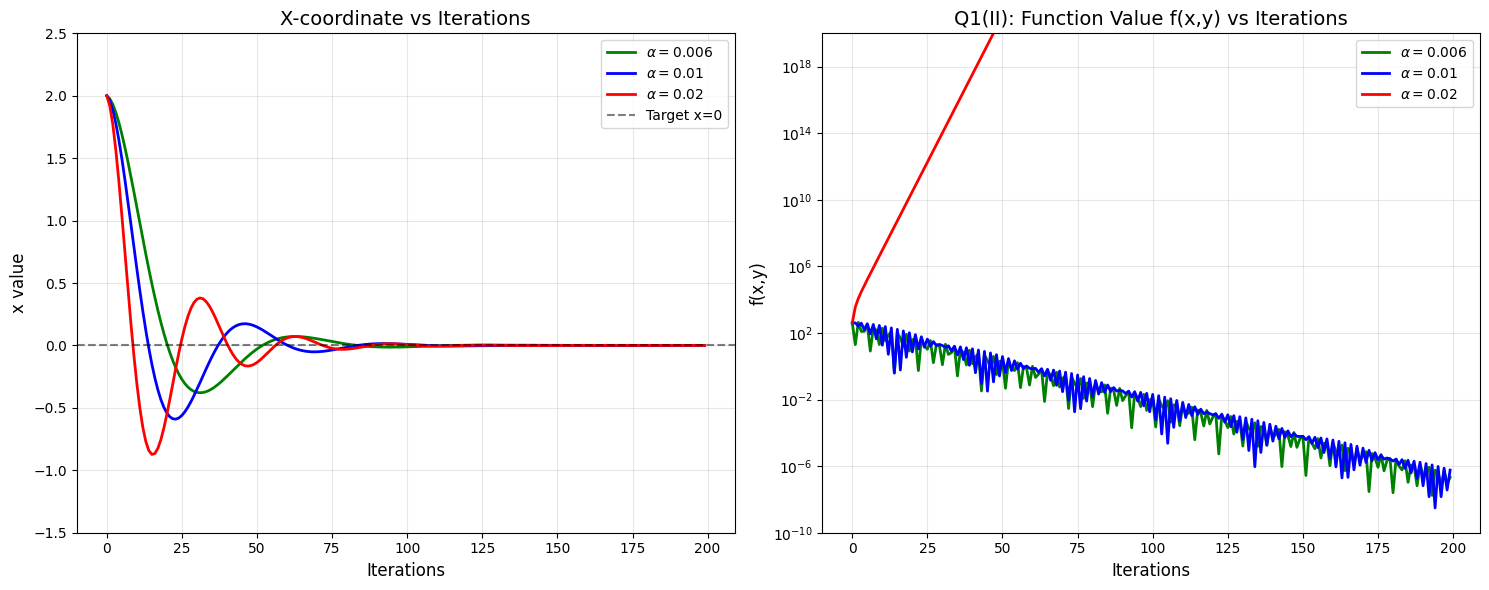

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the objective function and its gradient
def func(w):
    x, y = w[0], w[1]
    return x**2 + 100 * y**2

def gradient(w):
    x, y = w[0], w[1]
    return np.array([2*x, 200*y])

# Heavy Ball optimization algorithm
def run_heavy_ball(w_init, iterations, alpha, beta=0.9):
    w = w_init.copy()
    v = np.zeros_like(w) # Initialize velocity to 0
    
    # Record historical data
    x_history = []    # Record x coordinates
    loss_history = [] # Record function values f(x,y)
    
    for t in range(iterations):
        x_history.append(w[0])
        loss_history.append(func(w))
        
        grad = gradient(w)
        
        # Heavy Ball update formula
        # v_new = beta * v_old - alpha * gradient
        v = beta * v - alpha * grad
        w = w + v
        
        # Stop running to prevent errors
        if not np.isfinite(func(w)):
            break
            
    return x_history, loss_history

# Initial parameters
w_init = np.array([2.0, 2.0])
iterations = 200
beta = 0.9
alphas = [0.006, 0.01, 0.02]
colors = ['green', 'blue', 'red']
labels = [r'$\alpha=0.006$', r'$\alpha=0.01$', r'$\alpha=0.02$']

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for i in range(3):
    alpha = alphas[i]
    color = colors[i]
    label = labels[i]
    
    x_hist, loss_hist = run_heavy_ball(w_init, iterations, alpha, beta)
    
    # Plot 1: X coordinate changes
    ax1.plot(x_hist, label=label, color=color, linewidth=2)
    
    # Plot 2: Function value changes
    ax2.semilogy(loss_hist, label=label, color=color, linewidth=2)

# Configure Plot 1
ax1.set_title('X-coordinate vs Iterations', fontsize=14)
ax1.set_xlabel('Iterations', fontsize=12)
ax1.set_ylabel('x value', fontsize=12)
ax1.axhline(0, color='black', linestyle='--', alpha=0.5, label='Target x=0') # Target line
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1.5, 2.5)

# Configure Plot 2
ax2.set_title('Q1(II): Function Value f(x,y) vs Iterations', fontsize=14)
ax2.set_xlabel('Iterations', fontsize=12)
ax2.set_ylabel('f(x,y)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3, which="both")
ax2.set_ylim(1e-10, 1e20)

plt.tight_layout()
plt.show()

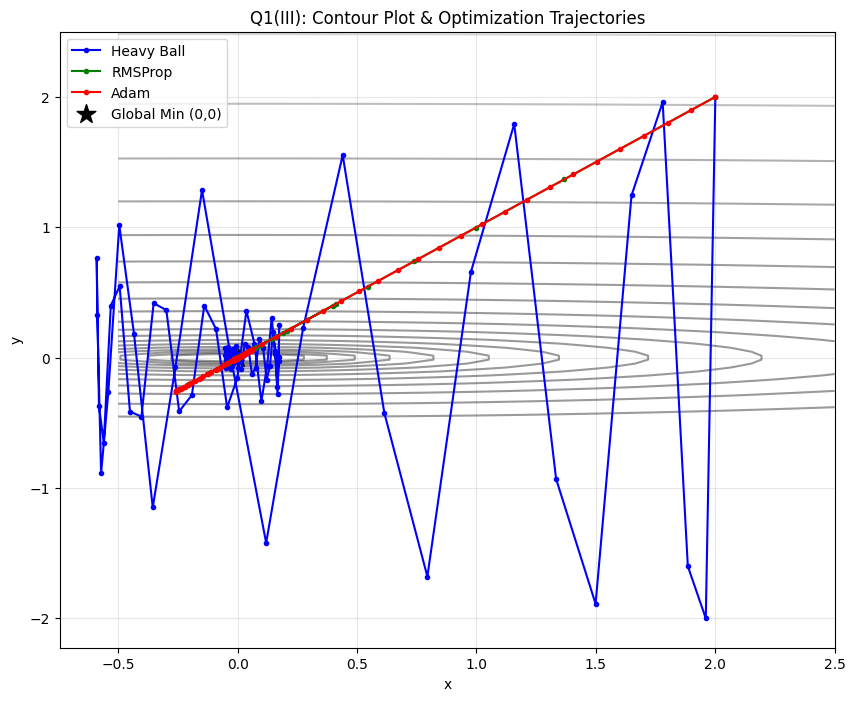

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def func(x, y):
    return x**2 + 100 * y**2

def gradient(w):
    x, y = w[0], w[1]
    return np.array([2*x, 200*y])

def run_optimizer(optimizer_func, w_init, iterations, **kwargs):
    w = w_init.copy()
    path = [w.copy()]
    
    # Initialize optimizer state
    state = {} 
    
    for i in range(iterations):
        w, state = optimizer_func(w, gradient(w), state,** kwargs)
        path.append(w.copy())
        
    return np.array(path)


def step_heavy_ball(w, grad, state, alpha, beta):
    # Initialize momentum v
    v = state.get('v', np.zeros_like(w))
    
    # Update step
    v = beta * v - alpha * grad
    w_new = w + v
    
    state['v'] = v
    return w_new, state

def step_rmsprop(w, grad, state, alpha, beta, epsilon=1e-8):
    # Initialize moving average of squared gradients s
    s = state.get('s', np.zeros_like(w))
    
    # Update step
    s = beta * s + (1 - beta) * (grad**2)
    w_new = w - alpha * grad / (np.sqrt(s) + epsilon)
    
    state['s'] = s
    return w_new, state

def step_adam(w, grad, state, alpha, beta1, beta2, epsilon=1e-8):
    m = state.get('m', np.zeros_like(w))
    v = state.get('v', np.zeros_like(w))
    t = state.get('t', 0)
    t += 1
    
    # Update step
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * (grad**2)
    
    # Bias correction
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    
    w_new = w - alpha * m_hat / (np.sqrt(v_hat) + epsilon)
    
    state['m'] = m
    state['v'] = v
    state['t'] = t
    return w_new, state


# Plotting
w_init = np.array([2.0, 2.0])
iterations = 100

# Get optimization trajectories
path_hb = run_optimizer(step_heavy_ball, w_init, iterations, alpha=0.01, beta=0.9)
path_rms = run_optimizer(step_rmsprop, w_init, iterations, alpha=0.2, beta=0.9)
path_adam = run_optimizer(step_adam, w_init, iterations, alpha=0.1, beta1=0.9, beta2=0.999)

plt.figure(figsize=(10, 8))
x_range = np.linspace(-0.5, 2.5, 100)
y_range = np.linspace(-0.5, 2.5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = func(X, Y)

# Plot contour lines
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='gray', alpha=0.4)

# Plot optimization trajectories
plt.plot(path_hb[:, 0], path_hb[:, 1], 'o-', label='Heavy Ball', markersize=3, color='blue')
plt.plot(path_rms[:, 0], path_rms[:, 1], 'o-', label='RMSProp', markersize=3, color='Green')
plt.plot(path_adam[:, 0], path_adam[:, 1], 'o-', label='Adam', markersize=3, color='red')

plt.scatter([0], [0], c='k', marker='*', s=200, label='Global Min (0,0)') # Mark the global minimum point

plt.title('Q1(III): Contour Plot & Optimization Trajectories')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

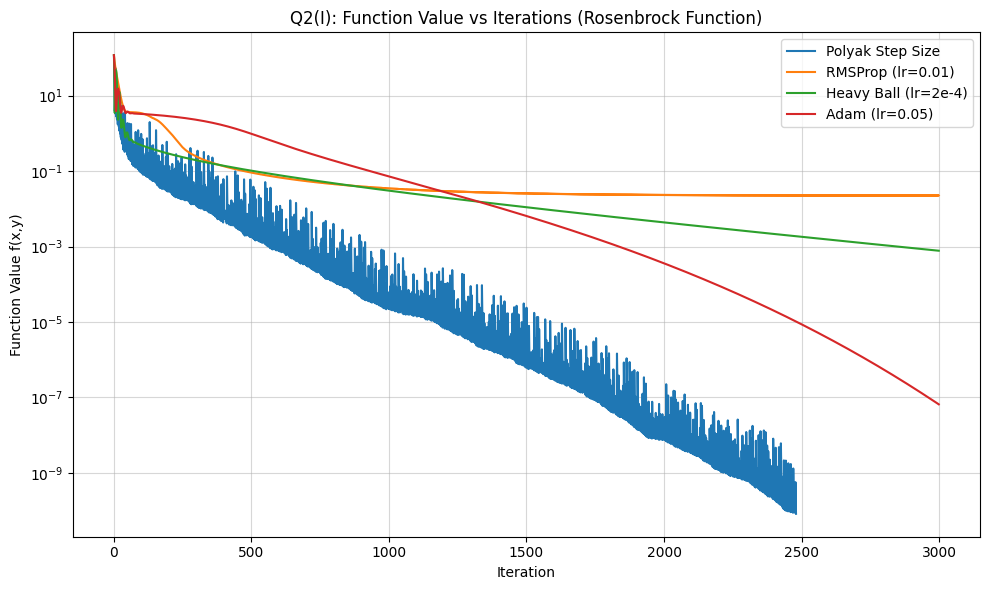

In [4]:
import numpy as np
import matplotlib.pyplot as plt


# Rosenbrock function and its gradient
def func_rosenbrock(w):
    x, y = w[0], w[1]
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosenbrock(w):
    x, y = w[0], w[1]
    # d/dx = -2(1-x) + 200(y-x^2)*(-2x)
    #      = -2 + 2x - 400x(y-x^2)
    grad_x = -2 * (1 - x) - 400 * x * (y - x**2)
    # d/dy = 200(y-x^2)
    grad_y = 200 * (y - x**2)
    return np.array([grad_x, grad_y])

def run_polyak_rosenbrock(w_init, iterations, max_step=0.1):
    w = w_init.copy()
    loss_history = []
    
    for t in range(iterations):
        loss = func_rosenbrock(w)
        loss_history.append(loss)
        
        grad = grad_rosenbrock(w)
        grad_norm_sq = np.sum(grad**2)
        
        if grad_norm_sq < 1e-10: 
            break
            
        # Polyak step size: (f(x) - f*) / ||grad||^2
        # Rosenbrock minimum value f* = 0
        step_size = loss / grad_norm_sq

        step_size = min(step_size, max_step)
        
        w = w - step_size * grad
        
    return loss_history

def run_heavy_ball(w_init, iterations, alpha, beta):
    w = w_init.copy()
    v = np.zeros_like(w)
    loss_history = []
    
    for t in range(iterations):
        loss_history.append(func_rosenbrock(w))
        grad = grad_rosenbrock(w)
        v = beta * v - alpha * grad
        w = w + v
    return loss_history

def run_rmsprop(w_init, iterations, alpha, beta, epsilon=1e-8):
    w = w_init.copy()
    s = np.zeros_like(w)
    loss_history = []
    
    for t in range(iterations):
        loss_history.append(func_rosenbrock(w))
        grad = grad_rosenbrock(w)
        s = beta * s + (1 - beta) * (grad**2)
        w = w - alpha * grad / (np.sqrt(s) + epsilon)
    return loss_history

def run_adam(w_init, iterations, alpha, beta1, beta2, epsilon=1e-8):
    w = w_init.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    loss_history = []
    
    for t in range(1, iterations + 1):
        loss_history.append(func_rosenbrock(w))
        grad = grad_rosenbrock(w)
        
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        w = w - alpha * m_hat / (np.sqrt(v_hat) + epsilon)
    return loss_history


# Initial settings
init_pos = np.array([-1.25, 0.5])
iterations = 3000

# Polyak
loss_polyak = run_polyak_rosenbrock(init_pos, iterations, max_step=0.1)

# Heavy Ball
loss_hb = run_heavy_ball(init_pos, iterations, alpha=2e-4, beta=0.9)

# RMSProp
loss_rmsprop = run_rmsprop(init_pos, iterations, alpha=0.01, beta=0.9)

# Adam
loss_adam = run_adam(init_pos, iterations, alpha=0.05, beta1=0.9, beta2=0.999)

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(loss_polyak, label='Polyak Step Size', linewidth=1.5)
plt.plot(loss_rmsprop, label='RMSProp (lr=0.01)', linewidth=1.5)
plt.plot(loss_hb, label='Heavy Ball (lr=2e-4)', linewidth=1.5)
plt.plot(loss_adam, label='Adam (lr=0.05)', linewidth=1.5)

plt.title('Q2(I): Function Value vs Iterations (Rosenbrock Function)')
plt.xlabel('Iteration')
plt.ylabel('Function Value f(x,y)')
plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

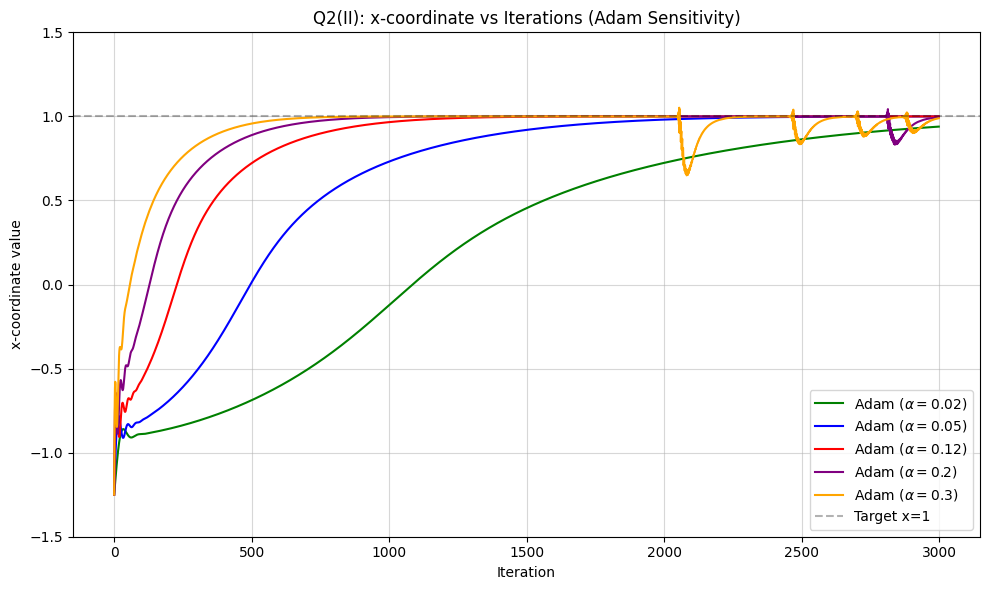

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def grad_rosenbrock(w):
    x, y = w[0], w[1]
    grad_x = -2 * (1 - x) - 400 * x * (y - x**2)
    grad_y = 200 * (y - x**2)
    return np.array([grad_x, grad_y])

def run_adam_trace_x(w_init, iterations, alpha, beta1=0.9, beta2=0.999, epsilon=1e-8):

    w = w_init.copy()
    m = np.zeros_like(w) # First moment
    v = np.zeros_like(w) # Second moment
    x_history = []
    
    for t in range(1, iterations + 1):
        x_history.append(w[0]) 
        
        grad = grad_rosenbrock(w)
        
        # Adam update
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        
        # Update parameters
        w = w - alpha * m_hat / (np.sqrt(v_hat) + epsilon)
        
        # Stop and fill remaining values if numerical explosion occurs
        if not np.isfinite(w).all():
            print(f"Warning: Instability detected at iteration {t} for alpha={alpha}")
            remaining = iterations - len(x_history)
            x_history.extend([np.nan] * remaining)
            break
            
    return x_history

# Initial parameters
w_init = np.array([-1.25, 0.5])
iterations = 3000
alphas = [0.02, 0.05, 0.12, 0.2, 0.3]

plt.figure(figsize=(10, 6))

colors = ['green', 'blue', 'red', 'purple', 'orange']
for i, alpha in enumerate(alphas):
    x_hist = run_adam_trace_x(w_init, iterations, alpha=alpha)
    plt.plot(x_hist, label=f'Adam ($\\alpha={alpha}$)', color=colors[i], linewidth=1.5)

# Plotting
plt.title('Q2(II): x-coordinate vs Iterations (Adam Sensitivity)')
plt.xlabel('Iteration')
plt.ylabel('x-coordinate value')
plt.axhline(1.0, color='black', linestyle='--', alpha=0.3, label='Target x=1') 
plt.ylim(-1.5, 1.5) 

plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

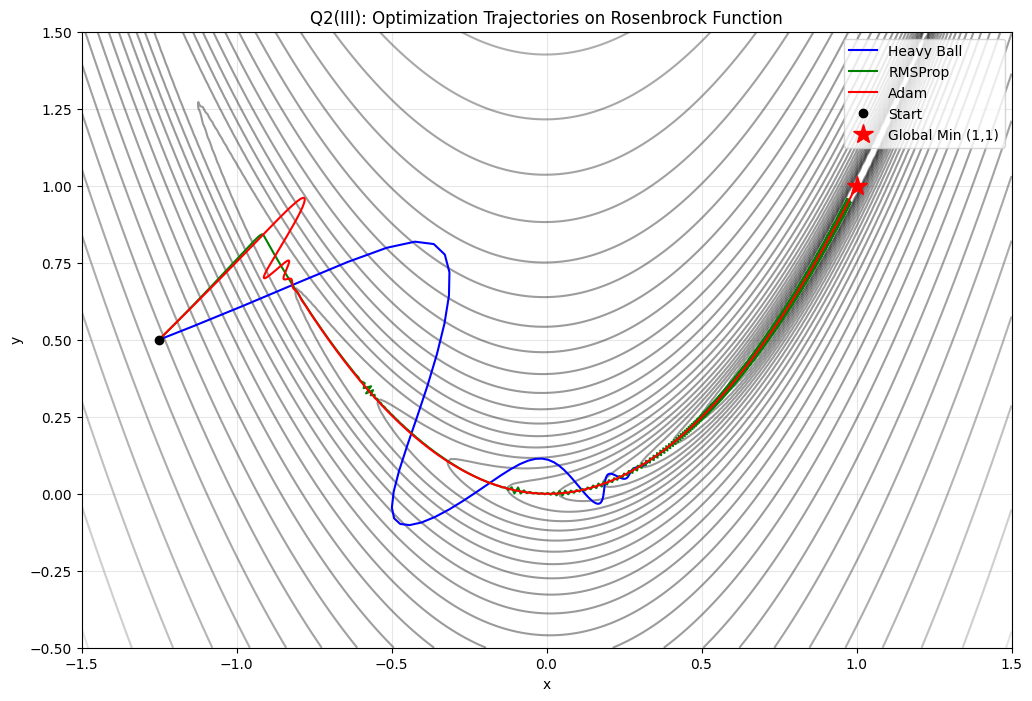

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def func_rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def grad_rosenbrock(w):
    x, y = w[0], w[1]
    grad_x = -2 * (1 - x) - 400 * x * (y - x**2)
    grad_y = 200 * (y - x**2)
    return np.array([grad_x, grad_y])

def get_optimizer_path(algo_name, w_init, iterations, **params):
    w = w_init.copy()
    path = [w.copy()]
    
    # Initialize state variables
    v = np.zeros_like(w) # Momentum / Second moment
    s = np.zeros_like(w) # RMSProp cache
    m = np.zeros_like(w) # Adam first moment
    
    for t in range(1, iterations + 1):
        grad = grad_rosenbrock(w)
        
        if algo_name == 'heavy_ball':
            alpha, beta = params['alpha'], params['beta']
            v = beta * v - alpha * grad
            w = w + v
            
        elif algo_name == 'rmsprop':
            alpha, beta = params['alpha'], params['beta']
            s = beta * s + (1 - beta) * (grad**2)
            w = w - alpha * grad / (np.sqrt(s) + 1e-8)
            
        elif algo_name == 'adam':
            alpha = params['alpha']
            beta1, beta2 = params['beta1'], params['beta2']
            
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad**2)
            
            m_hat = m / (1 - beta1**t)
            v_hat = v / (1 - beta2**t)
            
            w = w - alpha * m_hat / (np.sqrt(v_hat) + 1e-8)
            
        path.append(w.copy())
        
    return np.array(path)


w_init = np.array([-1.25, 0.5])
iterations = 3000

path_hb = get_optimizer_path('heavy_ball', w_init, iterations, alpha=2e-4, beta=0.9)
path_rms = get_optimizer_path('rmsprop', w_init, iterations, alpha=0.01, beta=0.9)
path_adam = get_optimizer_path('adam', w_init, iterations, alpha=0.05, beta1=0.9, beta2=0.999)

# Plotting
plt.figure(figsize=(12, 8))

x_vals = np.linspace(-1.5, 1.5, 200)
y_vals = np.linspace(-0.5, 1.5, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = func_rosenbrock(X, Y)

# Plot contour lines
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 30), cmap='gray', alpha=0.4)

# Plot optimization trajectories
plt.plot(path_hb[:, 0], path_hb[:, 1], label='Heavy Ball', color='blue', linewidth=1.5)
plt.plot(path_rms[:, 0], path_rms[:, 1], label='RMSProp', color='green', linewidth=1.5)
plt.plot(path_adam[:, 0], path_adam[:, 1], label='Adam', color='red', linewidth=1.5)

# Mark start point and end point (global minimum)
plt.plot(w_init[0], w_init[1], 'ko', label='Start')
plt.plot(1, 1, 'r*', markersize=15, label='Global Min (1,1)')

plt.title('Q2(III): Optimization Trajectories on Rosenbrock Function')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()